# Пример чтения файлов формата `.bag`
В данном блокноте приведен пример чтения технических данных из Робота Unitree A1 ИТ-Центра МАИ по имени Дора.
Данный формат широко распространен для записи технических параметров в системах ROS

Установка необходимых пакетов

In [ ]:
%pip install bagpy

Подключаем необходимые библиотеки:

In [ ]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
b = bagreader('20230117_183740.bag')

[INFO]  Data folder 20230117_183740 already exists. Not creating.


Посмотрим какие данные сохранены в файле

In [ ]:
#Если хотим посмотреть все топики в файле
#pd.set_option('display.max_rows', None)
b.topic_table

,Topics,Types,Message Count,Frequency
0,/device_0/info,diagnostic_msgs/KeyValue,13,NaN
1,/device_0/sensor_0/Depth_0/image/data,sensor_msgs/Image,394,14.988542
2,/device_0/sensor_0/Depth_0/image/metadata,diagnostic_msgs/KeyValue,9456,NaN
3,/device_0/sensor_0/Depth_0/info,realsense_msgs/StreamInfo,1,NaN
4,/device_0/sensor_0/Depth_0/info/camera_info,sensor_msgs/CameraInfo,1,NaN
...,...,...,...,...
102,/device_0/sensor_2/option/Frames_Queue_Size/de...,std_msgs/String,1,NaN
103,/device_0/sensor_2/option/Frames_Queue_Size/value,std_msgs/Float32,1,NaN
104,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/String,1,NaN
105,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/Float32,1,NaN


## Декодирование сообщений из топика

In [ ]:
msgsImu_MSG = b.message_by_topic('/device_0/sensor_2/Accel_0/imu/data')
msgsImu_MSG

'20230117_183740/device_0-sensor_2-Accel_0-imu-data.csv'

In [ ]:
df_msgsImu = pd.read_csv(msgsImu_MSG)
df_msgsImu

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,...,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8
0,0.000383,47404,1673969860,238107681,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.010330,47405,1673969860,247928381,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.020583,47406,1673969860,257749557,1,0.0,0.0,0.0,0.0,0.0,...,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.030097,47407,1673969860,267572165,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.041590,47408,1673969860,277393103,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2586,26.254508,50074,1673969886,483981609,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2587,26.264428,50075,1673969886,493787050,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2588,26.274125,50076,1673969886,503591537,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2589,26.283836,50077,1673969886,513395786,1,0.0,0.0,0.0,0.0,0.0,...,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Построим график для линейного ускорения датчика по оси Y.
Обратите внимание, что датчик в процессе эксперимента не перемещался, на него воздействовали лишь вибрации от вентилляторов, расположенных в корпусе робота.

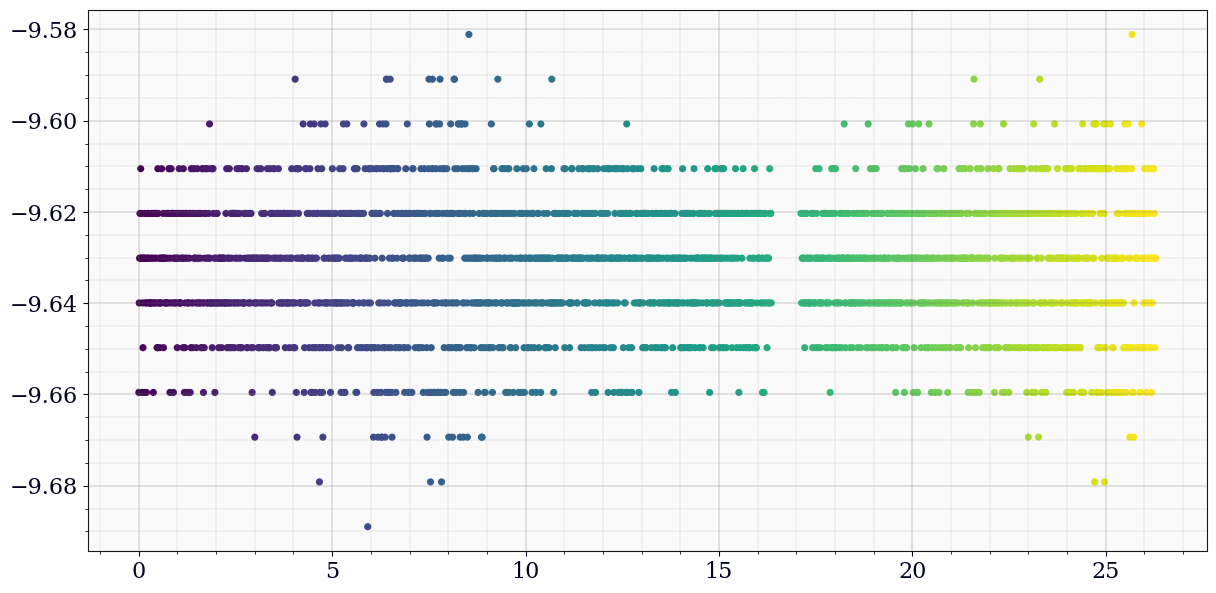

In [ ]:
fig, ax = bagpy.create_fig(1)
ax[0].scatter(x='Time', y='linear_acceleration.y', data=df_msgsImu, s= 17, c = 'Time')
plt.show()

## Заглянем в цветную камеру и камеру глубины
На борту робота установлена цветная камера и камера глубины, которые осуществляли съемку в процессе записи bag файла. Доступ к данным можно получить аналогичным способом

In [ ]:
sensor_msgsImage_MSG_depth = b.message_by_topic('/device_0/sensor_0/Depth_0/image/data')
sensor_msgsImage_MSG_rgb = b.message_by_topic('/device_0/sensor_1/Color_0/image/data')
sensor_msgsImage_MSG_rgb

'20230117_183740/device_0-sensor_1-Color_0-image-data.csv'

In [ ]:
df_sensor_msgsImage = pd.read_csv(sensor_msgsImage_MSG_rgb)
df_sensor_msgsImage

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.039579,6994,1673969860,210257769,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8d\x94\x8d\x8c...
1,0.106640,6995,1673969860,276888609,1,480,640,rgb8,0,1920,b'\x8c\x8b\x90\x8c\x8b\x90\x8d\x8b\x95\x8c\x8a...
2,0.174092,6996,1673969860,343518496,1,480,640,rgb8,0,1920,b'\x8c\x8e\x96\x8c\x8e\x96\x8a\x8e\x95\x8a\x8e...
3,0.239945,6997,1673969860,410146952,1,480,640,rgb8,0,1920,b'\x8e\x8c\x96\x8d\x8b\x95\x8d\x8b\x95\x8c\x8a...
4,0.307951,6998,1673969860,476774216,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8a\x93\x90\x8b...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.994066,7383,1673969886,155333042,1,480,640,rgb8,0,1920,b'\x88\x89\x91\x87\x88\x90\x87\x85\x8f\x88\x87...
390,26.058981,7384,1673969886,221859217,1,480,640,rgb8,0,1920,b'\x86\x8b\x8f\x85\x8a\x8e\x89\x88\x8f\x89\x88...
391,26.128662,7385,1673969886,288382292,1,480,640,rgb8,0,1920,b'\x86\x8c\x8d\x86\x8c\x8d\x84\x89\x8b\x86\x8c...
392,26.192559,7386,1673969886,354902267,1,480,640,rgb8,0,1920,b'\x87\x86\x8d\x87\x86\x8d\x88\x87\x8e\x88\x87...


In [ ]:
df_sensor_msgsImage_depth = pd.read_csv(sensor_msgsImage_MSG_depth)
df_sensor_msgsImage_depth

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.033964,6991,1673969860,210136890,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
1,0.101118,6992,1673969860,276767731,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
2,0.167259,6993,1673969860,343397617,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
3,0.234002,6994,1673969860,410026073,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
4,0.300807,6995,1673969860,476653337,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.986207,7380,1673969886,155212402,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
390,26.053176,7381,1673969886,221738577,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
391,26.119521,7382,1673969886,288261414,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
392,26.186304,7383,1673969886,354781628,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...


Далее можно считать изображение из Pandas DataFrame, однако в таком формате его использовать неудобно, поэтому добавим немного магии для преобразования в удобный вид цветного изображения

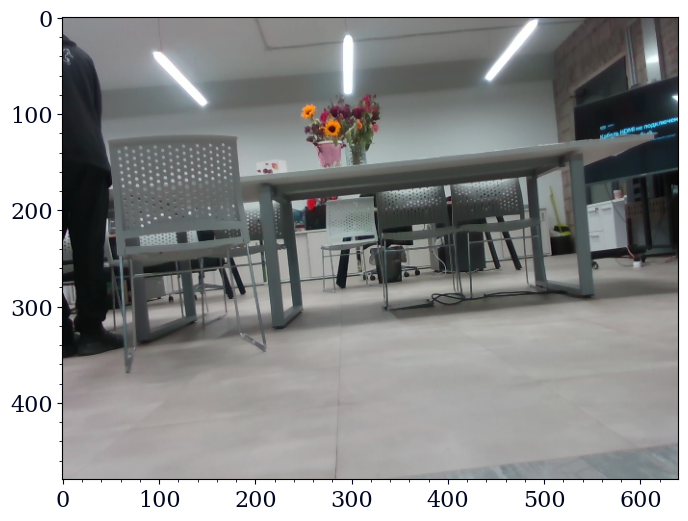

In [ ]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage['data'][0]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

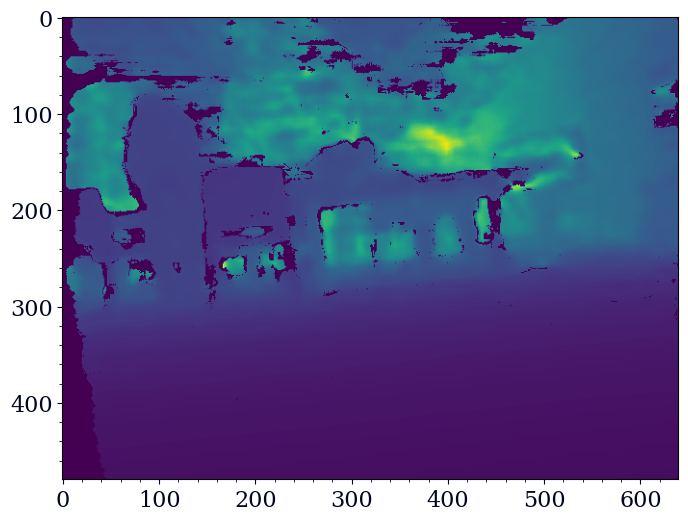

In [ ]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage_depth['data'][0]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.view(np.uint16).reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

## Практическое задание
* Попробуйте считать какие-либо параметры датчиков из данного файла, например, акселерометра
* Постройте параметры в виде графиков в matplotlib

In [1]:
%pip install bagpy
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
!pip install gdown

!ls /content

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.4/100.4 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.6/343.6 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.5/423.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 3.7 MB/s eta 0:00:00
  Created wheel for gnupg: filename=gnupg-2.3.1-py3-none-any.whl size=94614 sha256=73e2679576733b7987053395f99c255d2530a21adfaf9b75a2608254f53a37b0
  Stored in directory:

In [2]:
import gdown

file_id = "1qjwysZZL-BWMNTgqLbGxxRzWP_56rSrB"

url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "/content/20230117_183740.bag", quiet=False)

!ls /content



Downloading...
From (original): https://drive.google.com/uc?id=1qjwysZZL-BWMNTgqLbGxxRzWP_56rSrB
From (redirected): https://drive.google.com/uc?id=1qjwysZZL-BWMNTgqLbGxxRzWP_56rSrB&confirm=t&uuid=e4dc69e9-de63-46c0-9fdd-9157b859804b
To: /content/20230117_183740.bag
100%|██████████| 614M/614M [00:11<00:00, 52.7MB/s]

20230117_183740.bag  sample_data


In [3]:
b = bagreader('/content/20230117_183740.bag')

[INFO]  Successfully created the data folder /content/20230117_183740.


In [4]:
print(b.topic_table)

imu_topic = '/device_0/sensor_2/Gyro_0/imu/data'
imu_csv = b.message_by_topic(imu_topic)

                                                Topics  \
0                                       /device_0/info   
1                /device_0/sensor_0/Depth_0/image/data   
2            /device_0/sensor_0/Depth_0/image/metadata   
3                      /device_0/sensor_0/Depth_0/info   
4          /device_0/sensor_0/Depth_0/info/camera_info   
..                                                 ...   
102  /device_0/sensor_2/option/Frames_Queue_Size/de...   
103  /device_0/sensor_2/option/Frames_Queue_Size/value   
104  /device_0/sensor_2/option/Global_Time_Enabled/...   
105  /device_0/sensor_2/option/Global_Time_Enabled/...   
106                                      /file_version   

                         Types  Message Count  Frequency  
0     diagnostic_msgs/KeyValue             13        NaN  
1            sensor_msgs/Image            394  14.988542  
2     diagnostic_msgs/KeyValue           9456        NaN  
3    realsense_msgs/StreamInfo              1        NaN  
4       

In [5]:
df_imu = pd.read_csv(imu_csv)
print(df_imu.head())
print(df_imu.info())

       Time  header.seq  header.stamp.secs  header.stamp.nsecs  \
0  0.000015       92990         1673969860           237489462   
1  0.005167       92991         1673969860           242477894   
2  0.009925       92992         1673969860           247466326   
3  0.014939       92993         1673969860           252454519   
4  0.020369       92994         1673969860           257442951   

   header.frame_id  orientation.x  orientation.y  orientation.z  \
0                1            0.0            0.0            0.0   
1                1            0.0            0.0            0.0   
2                1            0.0            0.0            0.0   
3                1            0.0            0.0            0.0   
4                1            0.0            0.0            0.0   

   orientation.w  orientation_covariance_0  ...  linear_acceleration.z  \
0            0.0                       0.0  ...                    0.0   
1            0.0                       0.0  ...     

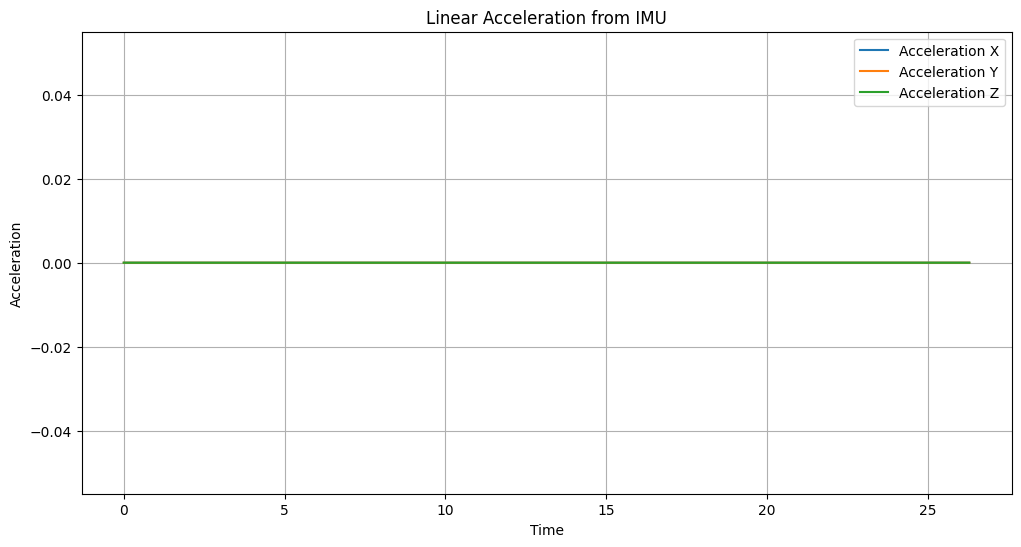

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(df_imu['Time'],
         df_imu['linear_acceleration.x'],
         label='Acceleration X')

plt.plot(df_imu['Time'],
         df_imu['linear_acceleration.y'],
         label='Acceleration Y')

plt.plot(df_imu['Time'],
         df_imu['linear_acceleration.z'],
         label='Acceleration Z')

plt.xlabel('Time')
plt.ylabel('Acceleration')
plt.title('Linear Acceleration from IMU')

plt.legend()
plt.grid()

plt.show()

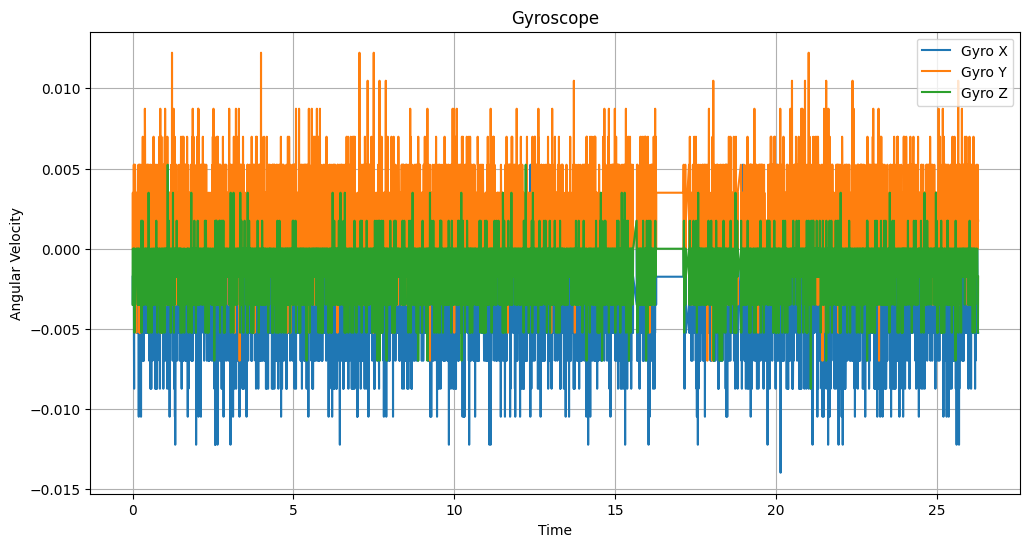

In [10]:
plt.figure(figsize=(12,6))

plt.plot(df_imu['Time'],
         df_imu['angular_velocity.x'],
         label='Gyro X')

plt.plot(df_imu['Time'],
         df_imu['angular_velocity.y'],
         label='Gyro Y')

plt.plot(df_imu['Time'],
         df_imu['angular_velocity.z'],
         label='Gyro Z')

plt.xlabel('Time')
plt.ylabel('Angular Velocity')

plt.title('Gyroscope')

plt.legend()
plt.grid()

plt.show()

## Дополнительная информация
Дополнительная информация по данному пакету доступна по [ссылке](https://pypi.org/project/bagpy/)